This script makes VCC images that can be used for distgen from the raw files taken in one of three formats:<br> .npy <br> image files <br> from the DAQ.  <br>  To be pulled from the DAQ, the raw_file location must be None

## User Input
Choose which dataset to work on

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements

In [125]:
import numpy as np
import pandas as pd
import os
import glob
import copy
from Image_Analysis import *
import imageio
import matplotlib.pyplot as plt
import cv2
from PIL import Image

## Manipulate Inputs

In [126]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)


## Load VCC Raw Images

In [127]:
if raw_vcc != 'included':
    if raw_vcc is not None:
        files = glob.glob(raw_vcc)
        try:
            vcc_list = []
            for file in files:
                img = np.load(file,allow_pickle=True)
                img_test = img.item()['CAMR:LT10:900:Image:ArrayData']
                img_test = np.reshape(img_test,[img.item()['CAMR:LT10:900:Image:ArraySize1_RBV'],img.item()['CAMR:LT10:900:Image:ArraySize0_RBV']])
                vcc_list.append(img_test)
        except Exception as e:
            print(e)
            vcc_list = []
            for file in files:
                vcc_list.append(imageio.imread(file))
    else:
        All_DAQ_df = pd.read_pickle(save_loc + "All_DAQ_Data.pkl")
        vcc_list = []
        for i,row in All_DAQ_df.iterrows():
            try:
                img = row['VCCF_images']
                img = np.reshape(img,[int(row['VCCF_nrows']),int(row['VCCF_ncols'])])
                vcc_list.append(img)
            except:
                pass
            

## Show raw images

In [128]:
if raw_vcc != 'included':
    j = 0
    for img in vcc_list:
        plt.imshow(img,vmax=10)
        plt.title(str(j))
        plt.show()
        if j>=9:
            break
        j = j+1

# USER INPUT
choose VCC image


In [129]:
if raw_vcc != 'included':
    idx = 0 

    vcc_img = vcc_list[idx]

# USER INPUT
choose ROI

In [130]:
if raw_vcc != 'included':
    bounds = {'xstart': 170,'xend': 1170,'ystart': 0, 'yend': 900} #Jan 2024
    bounds = {'xstart': 290,'xend': 1090,'ystart': 135, 'yend': 935} #March 2024


    outer_rad = 500

    bounds = {'xstart': 275,'xend': 1075,'ystart': 100, 'yend': 900}
    bounds = {'xstart': 285,'xend': 1085,'ystart': 100, 'yend': 900}
    bounds = {'xstart': 295,'xend': 1095,'ystart': 120, 'yend': 920}

    bounds = {'xstart': 150,'xend': 1150,'ystart': 0, 'yend': 1000} #Jan 2025
    outer_rad = 500

## Crop(p) image

In [131]:
if raw_vcc != 'included':
    vcc_img = vcc_img[bounds['ystart']:bounds['yend'],bounds['xstart']:bounds['xend']]

## Make mask

In [132]:
if raw_vcc != 'included':
    mask = np.zeros([np.shape(vcc_img)[0],np.shape(vcc_img)[1],3])
    mask = cv2.ellipse(mask,(int(np.shape(vcc_img)[0]/2),int(np.shape(vcc_img)[1]/2)),(int(np.shape(vcc_img)[0]/2),int(np.shape(vcc_img)[1]/2)),0,0,360,(1,0,0), -1)
    mask = mask[:,:,0]    

## Manipulate image
Get background <br>
subtract background<br>
threshold<br>
mask<br>


In [133]:
if raw_vcc != 'included':
    bg = np.mean(vcc_img[mask==0])
    vcc_img = (vcc_img-bg)*mask
    vcc_img[vcc_img<0] = 0


In [134]:
if raw_vcc != 'included':
    plt.imshow(vcc_img)

## Save Images

In [135]:
if raw_vcc != 'included':
    ## Flip Image
    vcc_img = np.flipud(np.fliplr(np.flipud(np.fliplr(np.flipud(vcc_img)))))

In [136]:
if raw_vcc != 'included':
    plt.imshow(vcc_img)

In [137]:
if raw_vcc != 'included':
    np.save(save_loc + 'VCC.npy',vcc_img)

In [138]:
if raw_vcc != 'included':
    im = Image.fromarray(vcc_img)
    if im.mode != 'RGB':
        im = im.convert('RGB')
    im.save(save_loc + "VCC.jpeg")

In [139]:
if raw_vcc != 'included':
    save_loc

6739


/tmp/ipykernel_2154261/719631750.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sizes.drop_duplicates(inplace=True)


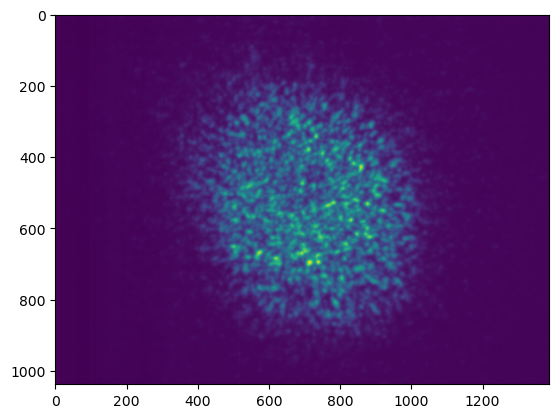

In [140]:
if raw_vcc == 'included':
    # Load All Data/All Images
    all_images_screen = np.load(save_loc + 'all_images_stack_' + screen_nickname + '.npy')
    # bg_cropp = np.load(save_loc + 'background_' + screen_nickname + '.npy')
    all_data = pd.read_pickle(save_loc + 'all_data_stack_' + screen_nickname + '.pkl')
    # moments_data = pd.read_hdf(save_loc + 'moments' + screen_nickname + '.h5')

    #Filter by which ones have a VCC image

    def filter_df(df, col):
        # Keep rows where the value is not None and not a string containing 'NaN'
        idx = (~df[col].isna()) & (df[col] != None) & (~df[col].astype(str).str.contains('NaN'))
        df_new = df[idx]
        return df_new, idx
        
    non_sync_data_screen, idx = filter_df(all_data,'CAMR:LT10:900:Image:ArrayData')
    print(len(non_sync_data_screen))

    # Remove all data rows and all image rows that do not have a VCC image
    if len(non_sync_data_screen)!=len(all_data):
        all_images_screen = all_images_screen[idx,:,:]
        all_data = all_data[idx]
        # moments_data = moments_data[idx]

    # Remove badly sized images
    df_sizes = all_data[['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize1_RBV','CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize0_RBV']]
    df_sizes.drop_duplicates(inplace=True)

    idx = []
    for i,row in df_sizes.iterrows():
        test = 0
        try:
            (int(row['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize0_RBV']))
        except:
            test = test +1
        try:
            (int(row['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize1_RBV']))
        except:test = test+1
        idx.append(test)
        
    idx=np.array(idx)
    idx = idx>=1
    idx
    df_sizes = df_sizes.loc[~idx]

    # Reshape all images
    def im_stack_from_df(df,col,ncolcol,nrowcol,fliplr=0,rot=0):
        ncols=df[ncolcol]
        nrows=df[nrowcol]
        if np.abs(np.sum(np.diff(ncols)))+np.abs(np.sum(np.diff(nrows)))==0:
            ncol=int(ncols.mean())
            nrow=int(nrows.mean())
            imgs=df[col]
            if rot:
                imgArray=np.zeros([len(imgs),nrow,ncol])
            else:
                imgArray=np.zeros([len(imgs),ncol,nrow])
            j=0
            
            for i,row in df.iterrows():
                # print(i)
                # print(j)
                img=imgs.iloc[j]
                # plt.imshow(img)
                # print(j)
                
                img=np.reshape(img,(ncol,nrow))
                if rot:
                    img=scipy.ndimage.rotate(img,90)
                if fliplr:
                    img=np.fliplr(img)
                imgArray[j,:,:]=img
                j=j+1
        return imgArray

    # Make VCC Image stack
    imgArray_List = []
    df_list = []
    moments_list = []
    all_images_screen_list = []
    for i, row in df_sizes.iterrows():
        idx1 = all_data['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize1_RBV']==row['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize1_RBV']
        idx2 = all_data['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize0_RBV']==row['CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize0_RBV']
        idx = idx1*idx2
        df_subset = all_data.loc[idx]
        # moments_subset = moments_data.loc[idx]
        all_images_screen_subset = all_images_screen[idx,:,:]
        all_images_screen_list.append(all_images_screen_subset)
        # moments_list.append(moments_subset)
        df_list.append(df_subset)
        imgArray=im_stack_from_df(df_subset,'CAMR:LT10:900:Image:ArrayData','CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize1_RBV','CAMR:LT10:900:Image:ArrayData'.split('Image:')[0] + 'Image:ArraySize0_RBV',fliplr=0,rot=0)
        imgArray_List.append(imgArray)
    # vcc_img_stack = im_stack_from_df(non_sync_data_screen,'CAMR:LT10:900:Image:ArrayData','CAMR:LT10:900:Image:ArraySize1_RBV','CAMR:LT10:900:Image:ArraySize0_RBV')
    # Flip all images in the stack vertically (along the second axis, i.e., axis=1)
    # vcc_img_stack = np.flip(vcc_img_stack, axis=1)
    for i in range(len(imgArray_List)):
        img_temp = np.sum(imgArray_List[i],0)
        plt.figure()
        plt.imshow(np.sum(imgArray_List[i],0))
        plt.show()


    

    # Do Analysis on VCC images
    # plt.imshow(np.mean(vcc_img_stack, axis=0))

    # Save VCC image stack
    # np.save(save_loc + 'vcc_image_stack_' + screen_nickname + '.npy', vcc_img_stack)


# USER INPUT HERE Crop images

In [141]:
if raw_vcc == 'included':
    # bound_list = [{'xstart': 600,'xend': 900,'ystart': 300, 'yend': 600}] # June


    bound_list = [{'xstart': 290,'xend': 1090,'ystart': 100, 'yend': 900}] # April 2024
    bound_list = [{'xstart': 260,'xend': 1060,'ystart': 100, 'yend': 900}] # January 2024
    # bound_list = [{'xstart': 250,'xend': 1050,'ystart': 100, 'yend': 900}] # January 2024
    # bound_list = [{'xstart': 290,'xend': 1090,'ystart': 140, 'yend': 940}] # March 2024
    bound_list = [{'xstart': 285,'xend': 1085,'ystart': 110, 'yend': 910}] # October 2024
    bound_list = [{'xstart': 235,'xend': 1135,'ystart': 60, 'yend': 960}] # January 2025

    image_stack = []
    for i in range(len(bound_list)):
        imArray = imgArray_List[i]
        test = imArray[:,bound_list[i]['ystart']:bound_list[i]['yend'],bound_list[i]['xstart']:bound_list[i]['xend']]
        image_stack.append(test)

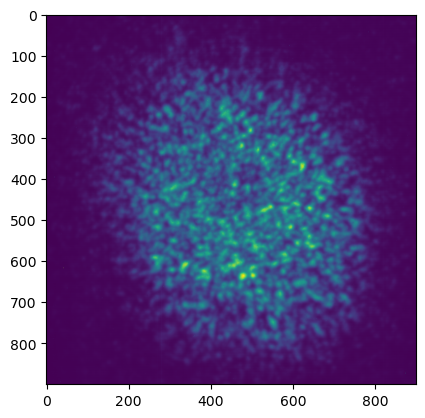

<Figure size 640x480 with 0 Axes>

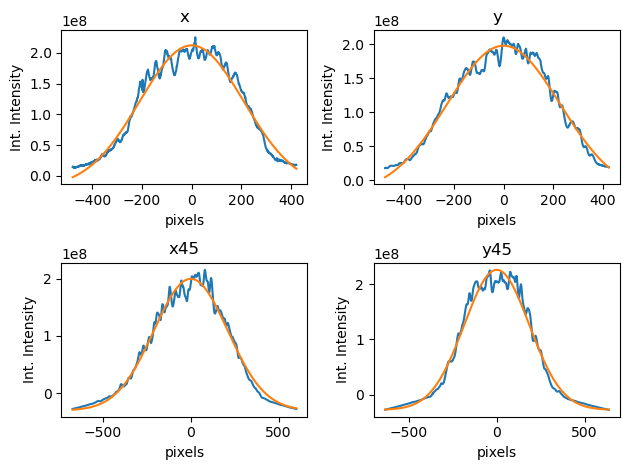

In [142]:
if raw_vcc == 'included':
    xcs = []
    ycs = []

    for i in range(len(imgArray_List)):
        img_temp = np.sum(image_stack[i],0)
        plt.figure()
        plt.imshow(img_temp)
        plt.show() 
        xfit,yfit,xfit45,yfit45 = Gaussian_Fit_4_Dim(img_temp)
        visualize_projections(img_temp)
        xcs.append(xfit.Center)
        ycs.append(yfit.Center)

In [143]:
if raw_vcc == 'included':
    all_images = np.concatenate(image_stack)
    all_images_screen = np.concatenate(all_images_screen_list)

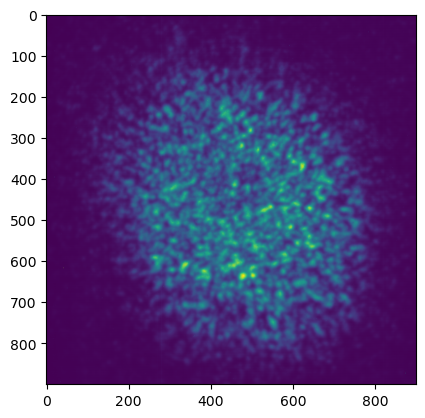

In [144]:
if raw_vcc == 'included':
    plt.imshow(np.sum(all_images,0))

In [145]:
if raw_vcc == 'included':
    imgs = []
    for i in range(np.shape(all_images)[0]):
        vcc_img = all_images[i,:,:]

        mask = np.zeros([np.shape(vcc_img)[0],np.shape(vcc_img)[1],3])
        mask = cv2.ellipse(mask,(int(np.shape(vcc_img)[0]/2),int(np.shape(vcc_img)[1]/2)),(int(np.shape(vcc_img)[0]/2),int(np.shape(vcc_img)[1]/2)),0,0,360,(1,0,0), -1)
        mask = mask[:,:,0]   
        bg = np.mean(vcc_img[mask==0])
        vcc_img = (vcc_img-bg)*mask
        vcc_img[vcc_img<0] = 0 
        imgs.append(vcc_img)
    all_images = np.array(imgs)

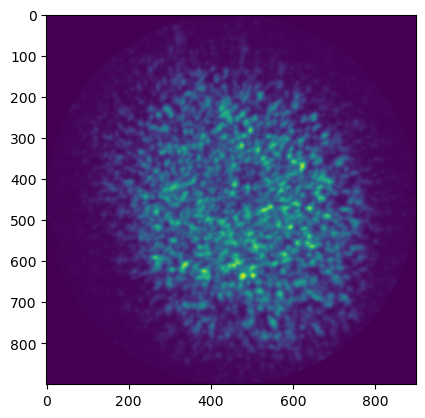

In [146]:
if raw_vcc == 'included':
    plt.imshow(np.sum(all_images,0))

In [24]:
if raw_vcc == 'included':
    all_data = pd.concat(df_list)
    moments_data = pd.concat(moments_list)
    plt.scatter(range(len(all_data)),all_data.index)
    plt.scatter(range(len(moments_data)),moments_data.index)

In [25]:
if raw_vcc == 'included':
    all_data.reset_index(drop=True,inplace=True)
    moments_data.reset_index(drop=True,inplace=True)

In [26]:

if raw_vcc == 'included':
    plt.scatter(range(len(all_data)),all_data.index)
    plt.scatter(range(len(moments_data)),moments_data.index)

In [27]:
## Save
if raw_vcc == 'included':
    rot_image_stack = np.flip(all_images,axis=1)
    np.save(save_loc + 'VCC_stack_' + screen_nickname + '.npy',rot_image_stack)
    np.save(save_loc + 'total_images_stack_' + screen_nickname + '.npy',all_images_screen)
    all_data.to_pickle(save_loc + 'total_data_stack_' + screen_nickname + '.pkl')
    moments_data.to_hdf(save_loc + 'moments' + screen_nickname + '.h5','moments')
    


In [28]:
np.shape(rot_image_stack)

NameError: name 'rot_image_stack' is not defined

In [ ]:
np.shape(all_images_screen)